In [42]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import emcee
import corner
from getdist import MCSamples, plots
import scipy

In [43]:
mpl.rcParams['font.size'] = 12  # Taille générale
mpl.rcParams['axes.titlesize'] = 16  # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 14  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 12  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 12  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 12  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 18  # Taille du titre de la figure

In [44]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.76
CoM_Name="CoM_CenA_M83_0.76"
row_name=CoM_Name

In [45]:
# file_path = '../data/data_'+CoM_Name+'_lg_big_errors.csv'
file_path = '../../data/generated_data_big.csv'
galaxy_df = pd.read_csv(file_path)

In [46]:
df=galaxy_df
mask = ~df['Name'].str.startswith('CoM_')
G = 4.3009e-9  # Constante gravitationnelle en (km/s)² Mpc / M☉

# Minor Infall

In [47]:
def velocity_model_1(B,x):
    """_summary_

    Args:
        B (array): is a vector of the parameters
        x (array):  x is an array of the current x values

    Returns:
        array: an array in the same format as y passed to Data or RealData
    """

    Omega_Lambda = 0.67
        
    return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)


In [48]:
def velocity_model_2(r, H0, M):
    G = 4.3009e-9  # constante gravitationnelle en m^3 kg^-1 s^-2
    n = 0.702

    r = np.array(r, dtype=np.float64)

    # Éviter les divisions par zéro ou racines de valeurs négatives
    r_safe = np.where(r == 0, np.nan, r)

    # Terme 1 : - (0.940 * H0 / R^n) * (GM / H0^2)^((n+1)/3)
    factor1 = -0.940 * H0 / np.power(r_safe, n)
    factor2 = np.power((G * M) / (H0 ** 2), (n + 1) / 3)

    term1 = factor1 * factor2

    # Terme 2 : + 1.335 * H0 * R
    term2 = 1.335 * H0 * r

    # Vitesse totale
    v = term1 + term2

    return v

In [49]:
def analyze_velocity_model(df, mask,velocity, row_name,velocity_model, xmin=1,xmax=15,plot=True):
    # -------------------
    # 1. Data preparation
    # -------------------
    df_clean = df.loc[mask, [
        'dis_center_' + row_name,
        velocity + '_' + row_name,
        'e_dis_center_min_' + row_name,
        'e_dis_center_max_' + row_name,
        'e_'+velocity+'_min_' + row_name,
        'e_'+velocity+'_max_' + row_name
    ]].apply(pd.to_numeric, errors='coerce').dropna()

    x = df_clean['dis_center_' + row_name].values
    y = df_clean[velocity+'_' + row_name].values

    xerr_low_full = df_clean['e_dis_center_min_' + row_name].values
    xerr_high_full = df_clean['e_dis_center_max_' + row_name].values
    yerr_low_full = df_clean['e_'+velocity+'_min_' + row_name].values
    yerr_high_full = df_clean['e_'+velocity+'_max_' + row_name].values

    # Apply the (0.5 <= x <= 5) mask uniformly
    mask_fit = (x >= xmin) & (x <= xmax) 
    x = x[mask_fit]
    y = y[mask_fit]
    xerr_low = xerr_low_full[mask_fit]
    xerr_high = xerr_high_full[mask_fit]
    yerr_low = yerr_low_full[mask_fit]
    yerr_high = yerr_high_full[mask_fit]
    
    # Calculate symmetrized errors for MCMC (missing in original)
    xerr_sym = (xerr_low + xerr_high) / 2
    yerr_sym = (yerr_low + yerr_high) / 2
    
    mydata = scipy.odr.RealData(x, y, sx=xerr_sym, sy=yerr_sym)
    
    # -------------------
    # 2. Define the model
    # -------------------
    linear = scipy.odr.Model(velocity_model)
    # -------------------
    # 3. Run ODR
    # -------------------
    myodr = scipy.odr.ODR(mydata, linear, beta0=[70, 1e13])
    myoutput = myodr.run()

    # -------------------
    # 5. get value
    # -------------------
# -------------------
# 5. Get values from ODR fit
# -------------------
    H0_mcmc, M_mcmc = myoutput.beta
    H0_uncertainty, M_uncertainty = myoutput.sd_beta  # Already scaled with residual variance
    
    if plot:
        # -------------------
        # 6. Plot best-fit model
        # -------------------
        # Fine grid for plotting
        r_plot = np.linspace(xmin, 15, 500)
        v_best = velocity_model([H0_mcmc, M_mcmc], r_plot)
    
        # Build 3-sigma credible band using Gaussian uncertainty propagation (optional):
        # Here we just create +/-3σ envelope (this is *not* a full posterior like MCMC)
        h0_samples = np.random.normal(H0_mcmc, H0_uncertainty, 1000)
        m_samples = np.random.normal(M_mcmc, M_uncertainty, 1000)
        v_samples = np.array([velocity_model([h0, m],r_plot) for h0, m in zip(h0_samples, m_samples)])
        v_lower = np.percentile(v_samples, 0.15, axis=0)
        v_upper = np.percentile(v_samples, 99.85, axis=0)
    
        # Plot
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.errorbar(x, y, xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
                    fmt='o', color='black', ecolor='red', capsize=5, label='Data')
    
        ax.plot(r_plot, v_best, 'r-', color='blue',
                label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$" + "\n" +
                       rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
        ax.fill_between(r_plot, v_lower, v_upper, color='blue', alpha=0.3,
                        label=rf"$3\sigma$ uncertainty")
    
        ax.set_xlabel("Distance from CoM (Mpc)")
        ax.set_ylabel(r"$v_{r}$ (km/s)")
        ax.grid(True)
        ax.set_xlim(0, 15)
        ax.set_ylim(-300, 1000)
        ax.legend()
        plt.show()
    
        return H0_mcmc, H0_uncertainty, M_mcmc, M_uncertainty
    else:
        return H0_mcmc, H0_uncertainty, M_mcmc, M_uncertainty

In [50]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_model_fitted(velocity,velocity_model,mask,H0,H0_sigma,M,M_sigma):
    def velocity_model(r, H0, M):
        Omega_Lambda = 0.67
        term1 = H0 * (1.1 + 0.31 * Omega_Lambda) * r
        term2 = 1.1 * np.sqrt(G * M / r)  
        return term1 - term2

    # === DISTANCES POUR COURBE THÉORIQUE ===
    r = np.linspace(0.5, 15, 300)
    v_r = velocity_model(r, H0, M)

    # Vitesse min/max pour zone d'incertitude
    v_r_min = velocity_model(r, H0 - H0_sigma, M - M_sigma)
    v_r_max = velocity_model(r, H0 + H0_sigma, M + M_sigma)

    # === EXTRACTION DES DONNÉES ===
    x = pd.to_numeric(df.loc[mask, 'dis_center_' + row_name], errors='coerce').values
    y = pd.to_numeric(df.loc[mask, velocity+"_" + row_name], errors='coerce').values
    names = df.loc[mask, 'Name'].astype(str).values  # Nom des galaxies

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # === ERREURS SUR DONNÉES ===
    col_e_x_max = 'e_dis_center_max_' + row_name
    col_e_x_min = 'e_dis_center_min_' + row_name
    col_e_y_max = 'e_'+velocity+'_max_' + row_name
    col_e_y_min = 'e_'+velocity+'_min_' + row_name

    if all(col in df.columns for col in [col_e_x_max, col_e_x_min, col_e_y_max, col_e_y_min]):
        e_x_min = pd.to_numeric(df.loc[mask, col_e_x_min], errors='coerce').values
        e_x_max = pd.to_numeric(df.loc[mask, col_e_x_max], errors='coerce').values
        e_y_min = pd.to_numeric(df.loc[mask, col_e_y_min], errors='coerce').values
        e_y_max = pd.to_numeric(df.loc[mask, col_e_y_max], errors='coerce').values

        # === TRAITEMENT DES GALAXIES SPECIALES ===
        special_mask = np.array(["cena" in name.lower() or "M83" in name.upper() for name in names])
        normal_mask = ~special_mask

        # Galaxies normales : ronds
        ax.errorbar(
            x[normal_mask], y[normal_mask],
            xerr=[e_x_min[normal_mask], e_x_max[normal_mask]],
            yerr=[e_y_min[normal_mask], e_y_max[normal_mask]],
            fmt='o', color='black', capsize=5, ecolor='red', label="Data"
        )

        # Galaxies spéciales : étoiles
        ax.errorbar(
            x[special_mask], y[special_mask],
            xerr=[e_x_min[special_mask], e_x_max[special_mask]],
            yerr=[e_y_min[special_mask], e_y_max[special_mask]],
            fmt='*', color='orange', capsize=5, ecolor='orange', markersize=20, label="CenA / M83"
        )

    # === COURBE THÉORIQUE + INCERTITUDE ===
    ax.plot(r, v_r, label=rf"Fit: $H_0 = {H0:.1f} \pm {H0_sigma:.1f}$"+ "\n"+ rf"$M = ({M/1e12:.2f} \pm {M_sigma/1e12:.2f}) \times 10^{{12}}\, M_\odot$", color='green')
    ax.fill_between(r, v_r_min, v_r_max, color='green', alpha=0.3, label="uncertainties")

    # === MISE EN FORME ===
    ax.set_xlabel("Distance from CoM (Mpc)")
    ax.set_ylabel(r"$v_r$ (km/s)")
    ax.set_xlim(0, 14)
    ax.set_ylim(-500, 1500)
    ax.grid(True)
    ax.legend()
    plt.show()


In [51]:
def plot_fit_max_dist(df,mask,row_name,velocity,velocity_model,xmin,xminmax,xmaxmax,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmax, xmaxmax, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma = analyze_velocity_model(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=xmin,xmax=k,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.set_yscale("log")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.set_yscale("log")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

In [52]:
def plot_fit_min_dist(df,mask,row_name,velocity,velocity_model,xmax,xminmin,xmaxmin,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmin, xmaxmin, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma = analyze_velocity_model(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=k,xmax=xmax,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: invalid value encountered in sqrt
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3923064268.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_best, 'r-', color='blue',


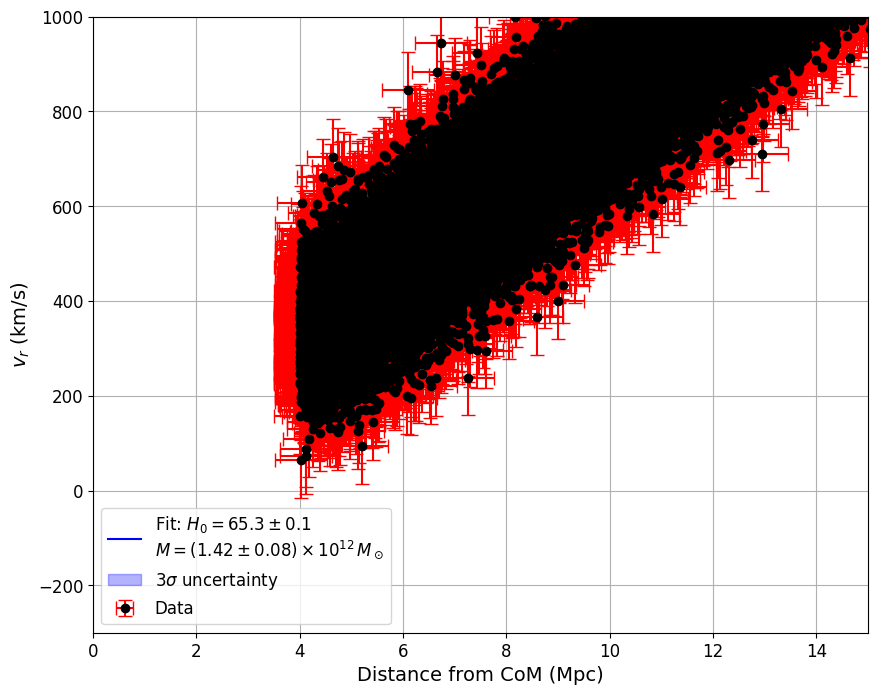

In [61]:
H0_min, H0_sigma_min, M_min, M_sigma_min = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=4, xmax=305)

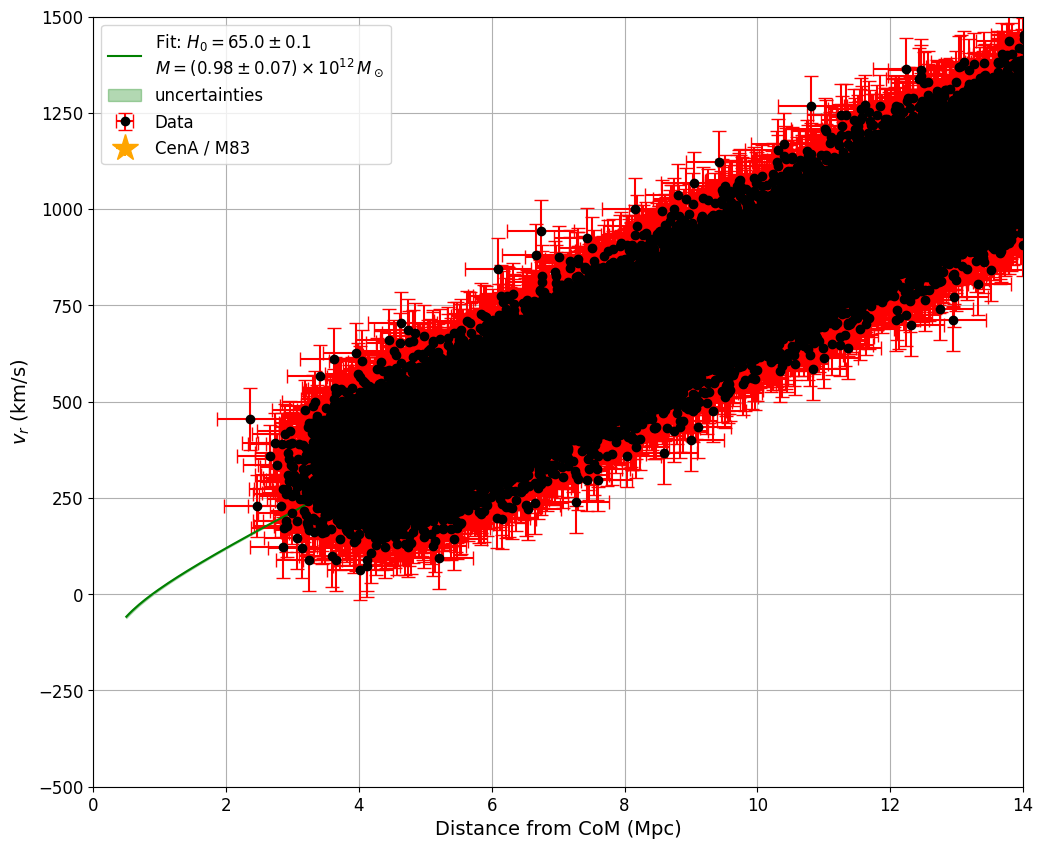

In [54]:
plot_model_fitted(velocity='minor_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_min,H0_sigma=H0_sigma_min,M=M_min,M_sigma=M_sigma_min)

# Major infall

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: divide by zero encountered in divide
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3923064268.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_best, 'r-', color='blue',


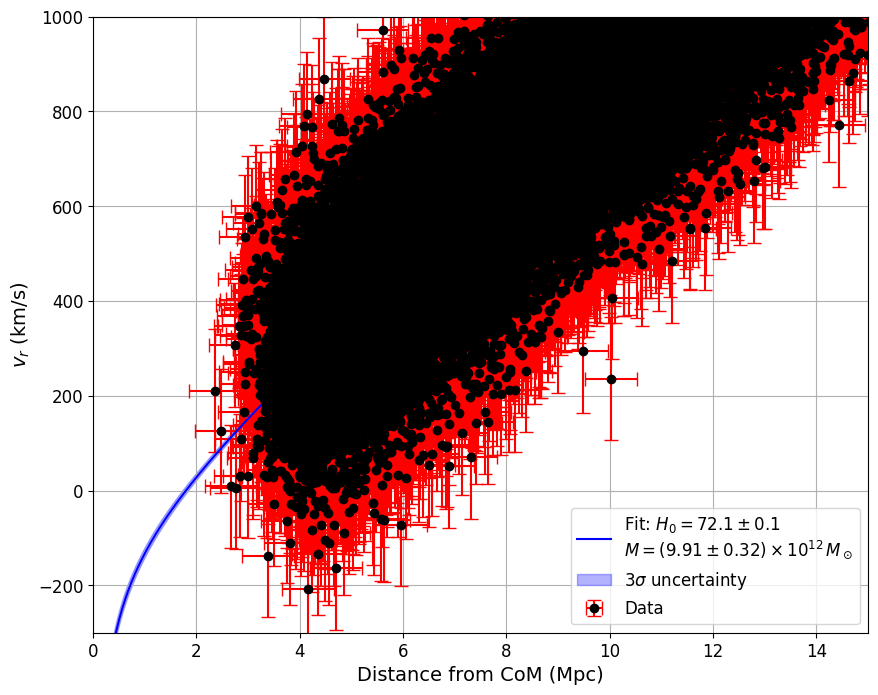

In [55]:
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)

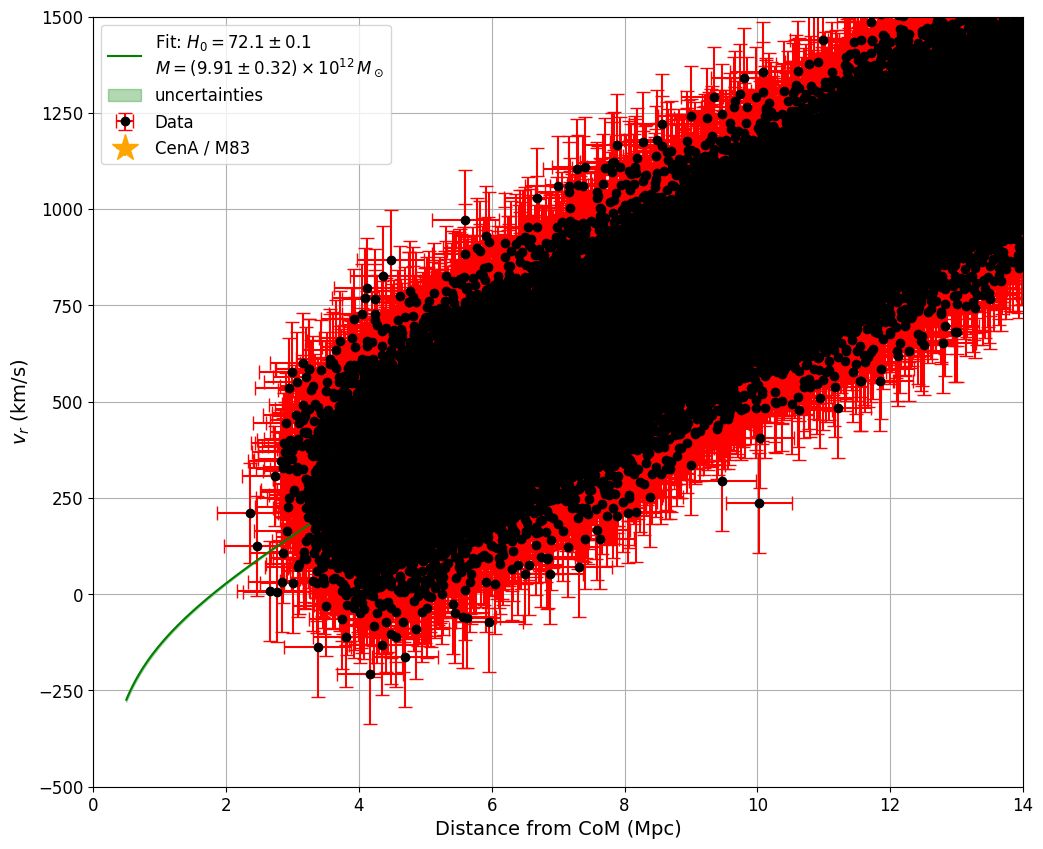

In [56]:
plot_model_fitted(velocity='major_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_maj,H0_sigma=H0_sigma_maj,M=M_maj,M_sigma=M_sigma_maj)

In [57]:
file_path = '../../data/generated_data_medium.csv'
galaxy_df = pd.read_csv(file_path)

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: invalid value encountered in sqrt
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: divide by zero encountered in divide
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3923064268.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_best, 'r-', color='blue',


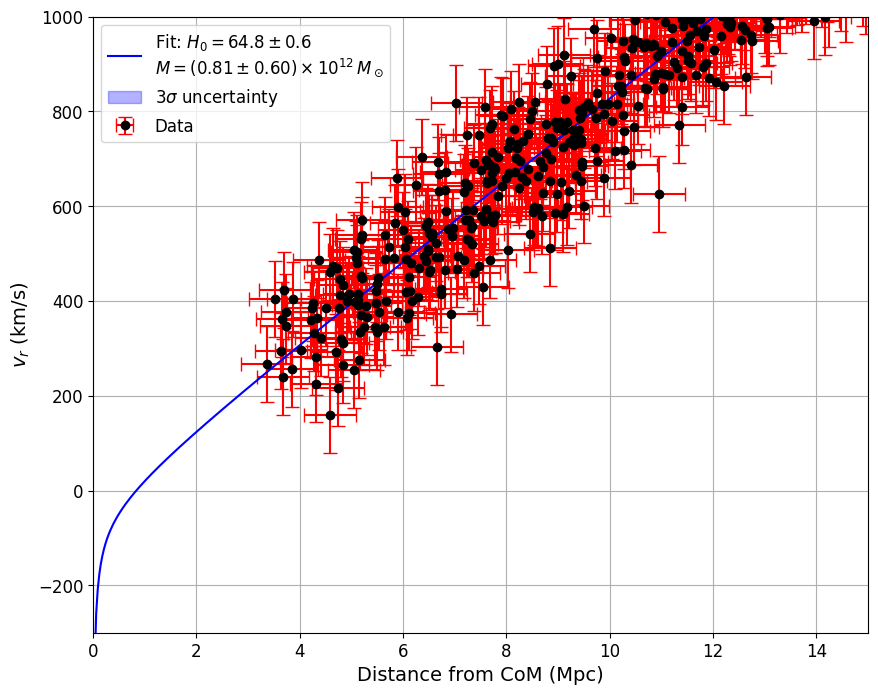

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: invalid value encountered in sqrt
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: divide by zero encountered in divide
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3923064268.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_best, 'r-', color='blue',


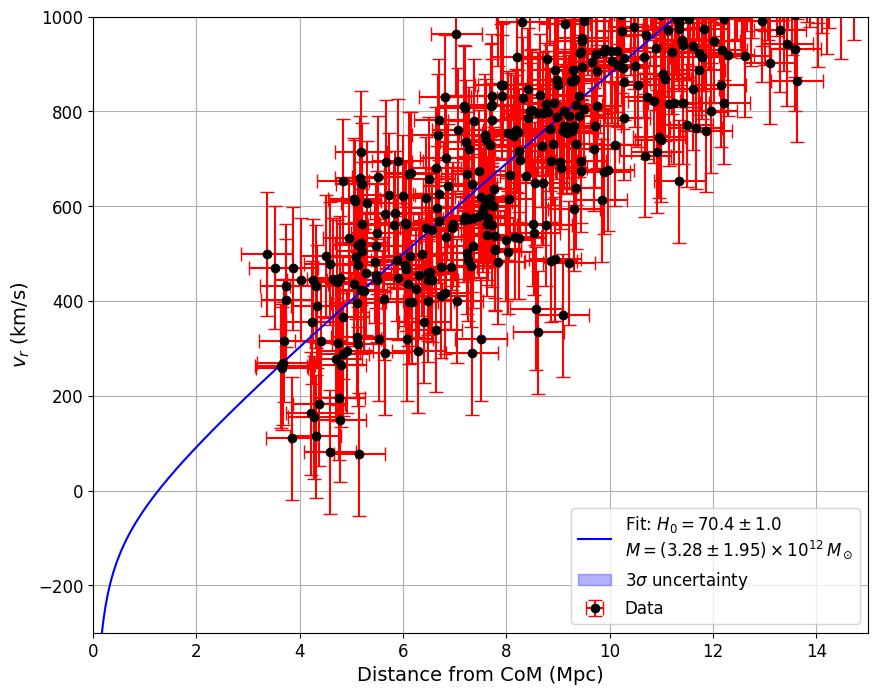

In [58]:
H0_min, H0_sigma_min, M_min, M_sigma_min = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=305)
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)

In [59]:
file_path = '../../data/generated_data_small.csv'
galaxy_df = pd.read_csv(file_path)

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: divide by zero encountered in divide
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: invalid value encountered in sqrt
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3923064268.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_best, 'r-', color='blue',


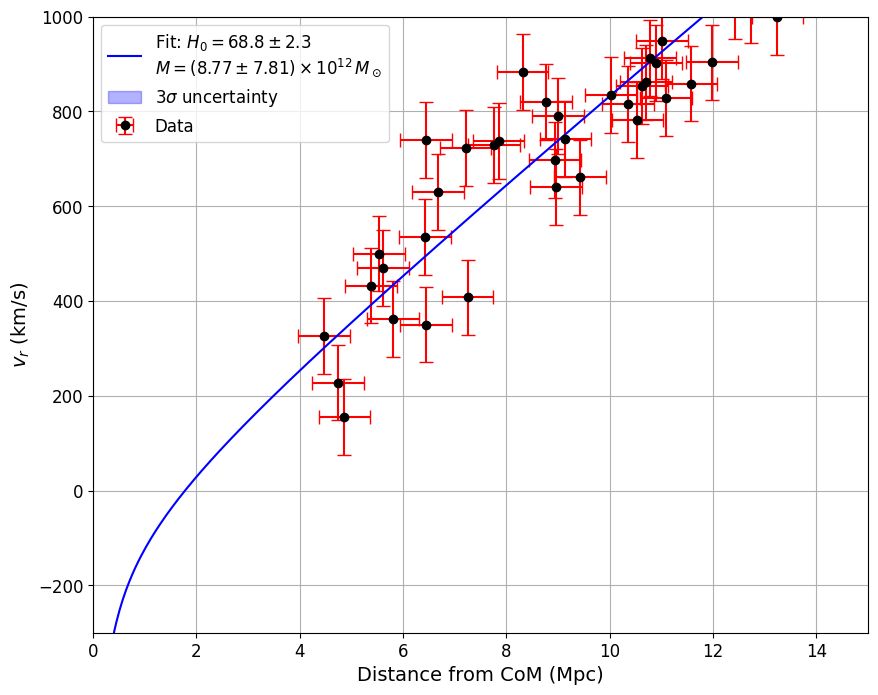

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: divide by zero encountered in divide
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3889055611.py:14: RuntimeWarning: invalid value encountered in sqrt
  return  B[0] * (1.1 + 0.31 * Omega_Lambda) * x - 1.1*np.sqrt(G * B[1] / x)
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_14116\3923064268.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_best, 'r-', color='blue',


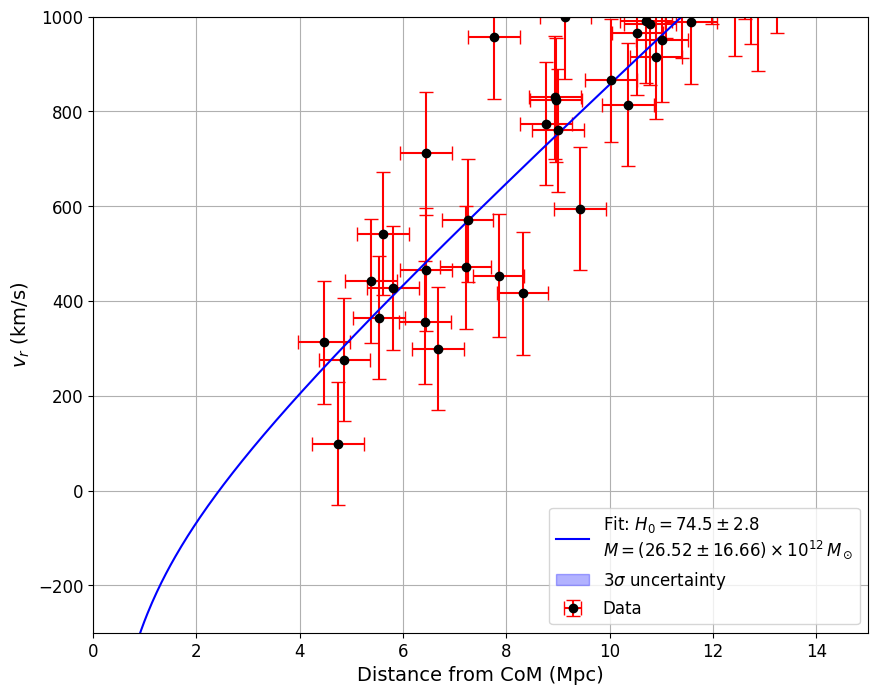

In [60]:
H0_min, H0_sigma_min, M_min, M_sigma_min = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=305)
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)